<a href="https://colab.research.google.com/github/ViswakowsikK2101/AI-Based-Heart-Disease-Risk-Prediction-System/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Loading and Exploration
We will begin by loading the `advertising.csv` dataset and inspecting its features to understand the relationship between advertising spend and sales.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/advertising.csv')

# Display basic info and first few rows
print("Dataset Info:")
display(df.info())
print("\nFirst 5 rows:")
display(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


None


First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


### 2. Exploratory Data Analysis (EDA)
Let's visualize the correlation between the features to see which advertising medium has the strongest impact on sales.

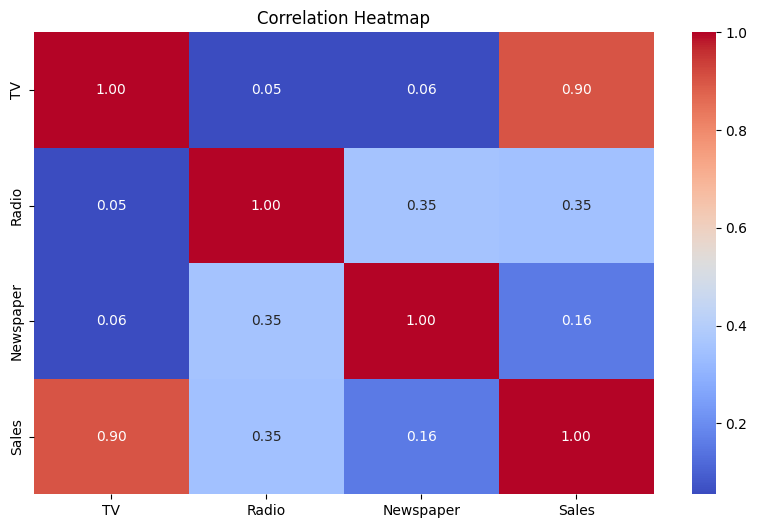

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 3. Model Training and Comparison
We will split the data into features (X) and target (y), then train Random Forest and XGBoost models.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Splitting the data
X = df.drop('Sales', axis=1)
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Training
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Evaluation helper function
def evaluate(y_true, y_pred, name):
    print(f'--- {name} Performance ---')
    print(f'R-squared: {r2_score(y_true, y_pred):.4f}')
    print(f'MSE: {mean_squared_error(y_true, y_pred):.4f}')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.4f}\n')

evaluate(y_test, rf_pred, 'Random Forest')
evaluate(y_test, xgb_pred, 'XGBoost')

--- Random Forest Performance ---
R-squared: 0.9535
MSE: 1.4374
MAE: 0.9180

--- XGBoost Performance ---
R-squared: 0.9574
MSE: 1.3163
MAE: 0.8751



### 4. Feature Importance
Let's visualize which advertising platform contributes most to the prediction.

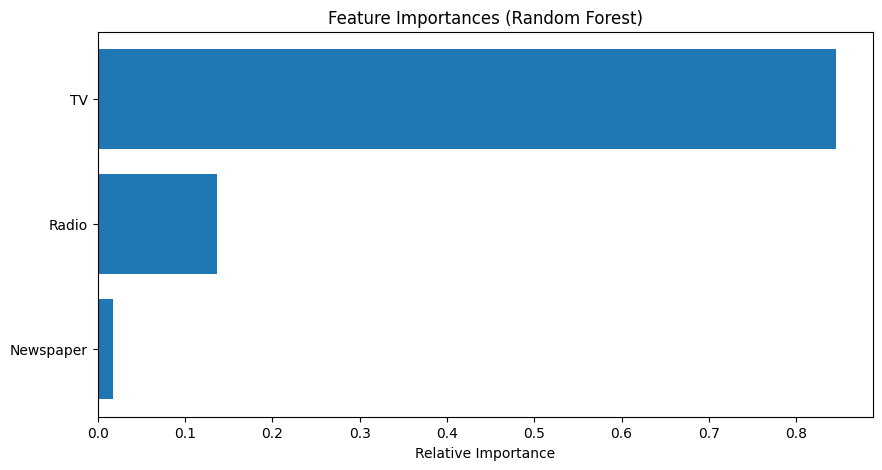

In [11]:
features = X.columns
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

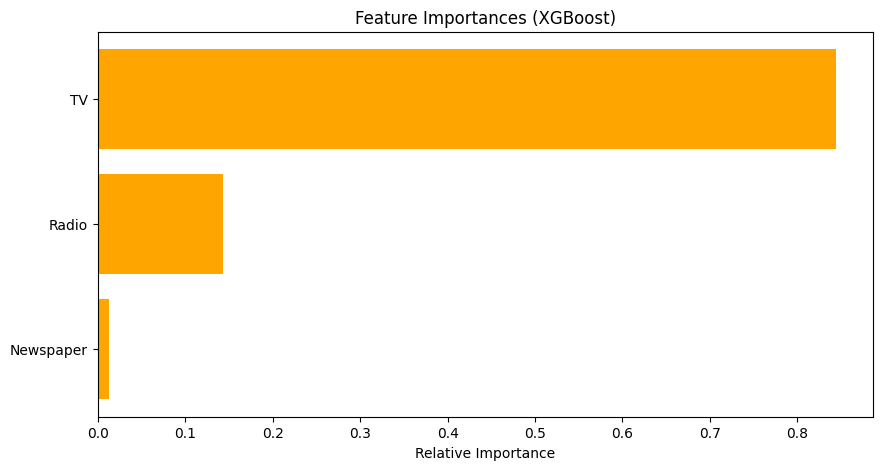

In [12]:
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)

plt.figure(figsize=(10, 5))
plt.title('Feature Importances (XGBoost)')
plt.barh(range(len(indices_xgb)), importances_xgb[indices_xgb], align='center', color='orange')
plt.yticks(range(len(indices_xgb)), [X.columns[i] for i in indices_xgb])
plt.xlabel('Relative Importance')
plt.show()